In [1]:
def monte_carlo_retirement(
    starting_balance=1_000_000,
    annual_withdrawal=40_000,
    years=30,
    num_simulations=10_000,
    stock_allocation=0.6,
    stock_mean_return=0.07, stock_std=0.15,
    bond_mean_return=0.03, bond_std=0.05,
    inflation=0.025
):
  bond_allocation = 1 - stock_allocation
  success_count = 0
  all_paths = []
  for _ in range(num_simulations):
    balance = starting_balance
    withdrawal = annual_withdrawal
    path = [balance]
    for year in range(years):
      stock_return = np.random.normal(stock_mean_return, stock_std)
      bond_return = np.random.normal(bond_mean_return, bond_std)
      portfolio_return = (stock_allocation * stock_return) + (bond_allocation * bond_return)
      balance = balance * (1 + portfolio_return) - withdrawal
      withdrawal *= (1 + inflation)
      path.append(max(balance, 0))
      if balance <= 0:
        break
    all_paths.append(path)
    if balance >0:
      success_count += 1
  success_rate = success_count / num_simulations
  return success_rate, all_paths

In [3]:
import numpy as np
success_rate, paths = monte_carlo_retirement()
print(success_rate)

0.7608


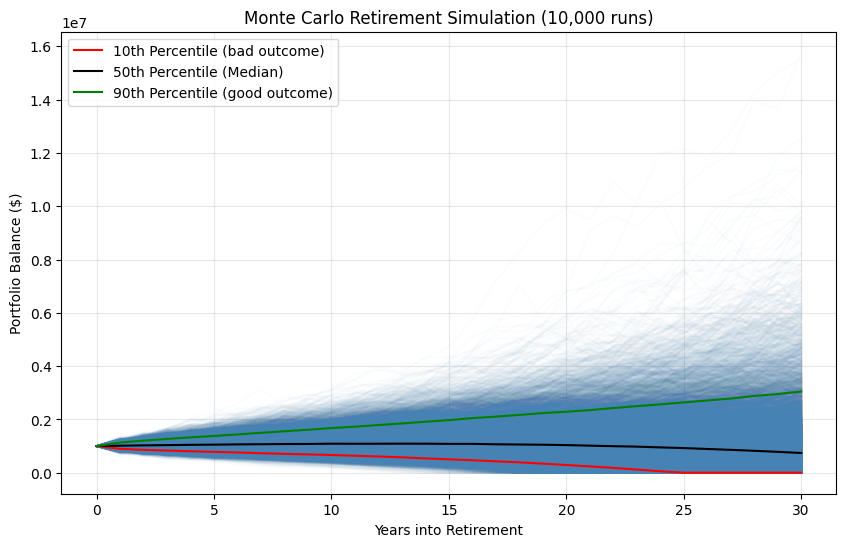

In [6]:
import matplotlib.pyplot as plt
years = 30
max_len = years + 1
padded_paths = []
for path in paths:
  padded = path + [0] * (max_len - len(path))
  padded_paths.append(padded)

paths_array = np.array(padded_paths)
plt.figure(figsize=(10, 6))
for path in paths_array:
  plt.plot(path, color='steelblue', alpha=0.02)
percentile_10 = np.percentile(paths_array, 10, axis=0)
percentile_50 = np.percentile(paths_array, 50, axis=0)
percentile_90 = np.percentile(paths_array, 90, axis=0)
plt.plot(percentile_10, color='red', label='10th Percentile (bad outcome)')
plt.plot(percentile_50, color='black', label='50th Percentile (Median)')
plt.plot(percentile_90, color='green', label='90th Percentile (good outcome)')
plt.title('Monte Carlo Retirement Simulation (10,000 runs)')
plt.xlabel('Years into Retirement')
plt.ylabel('Portfolio Balance ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
withdrawal_rates = [0.03, 0.04, 0.05]
starting_balance = 1_000_000
for rate in withdrawal_rates:
  annual_withdrawal = starting_balance * rate
  success_rate, _ = monte_carlo_retirement(
      starting_balance=starting_balance,
      annual_withdrawal=annual_withdrawal
  )
  print(f"withdrawal rate: {rate*100:.0f}% (${annual_withdrawal:,.0f}/year) -> Success rate: {success_rate*100:.1f}%")


withdrawal rate: 3% ($30,000/year) -> Success rate: 95.6%
withdrawal rate: 4% ($40,000/year) -> Success rate: 75.3%
withdrawal rate: 5% ($50,000/year) -> Success rate: 43.5%


In [8]:
withdrawal_rates = [0.03, 0.04, 0.05]
allocations = [0.4, 0.6, 0.8]  # % in stocks

results = []

for rate in withdrawal_rates:
    for alloc in allocations:
        annual_withdrawal = starting_balance * rate
        success_rate, _ = monte_carlo_retirement(
            starting_balance=starting_balance,
            annual_withdrawal=annual_withdrawal,
            stock_allocation=alloc
        )
        results.append({
            'withdrawal_rate': rate,
            'stock_allocation': alloc,
            'success_rate': success_rate
        })

In [10]:
import pandas as pd

df = pd.DataFrame(results)
pivot_table = df.pivot(index='withdrawal_rate', columns='stock_allocation', values='success_rate')
print(pivot_table)

stock_allocation     0.4     0.6     0.8
withdrawal_rate                         
0.03              0.9719  0.9547  0.9282
0.04              0.7011  0.7540  0.7597
0.05              0.2725  0.4491  0.5155


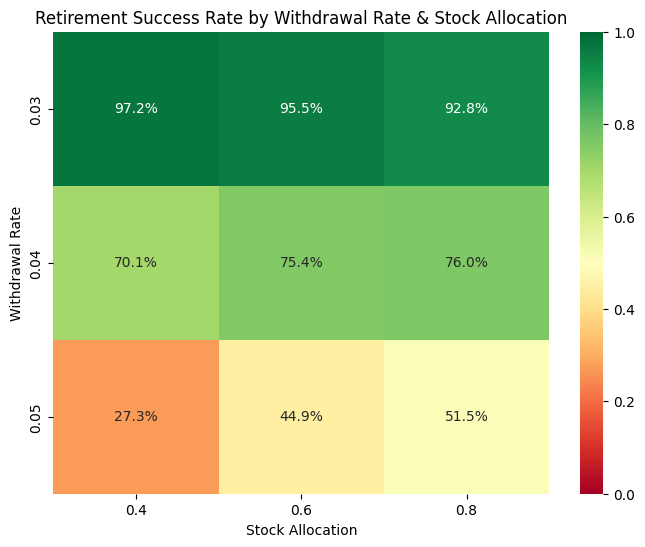

In [11]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Retirement Success Rate by Withdrawal Rate & Stock Allocation')
plt.xlabel('Stock Allocation')
plt.ylabel('Withdrawal Rate')
plt.show()